In [21]:
import torch
if torch.backends.mps.is_available():
    device = torch.device("mps")

torch.set_default_device(device)
print('Устройство:', device)

Устройство: mps


In [22]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import MNIST
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

## Данные

Данные: torch.Size([60000, 784])


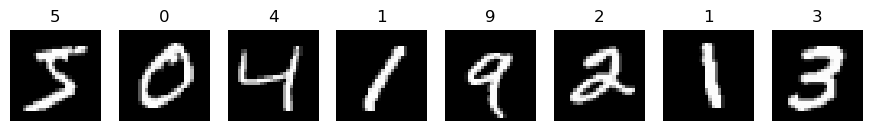

In [15]:
mnist = MNIST('./data', train=True, download=True)
X_all = mnist.data.float().view(-1, 784) / 255.0
y_all = mnist.targets.numpy()
idx = np.arange(len(X_all))
X = X_all[idx].to(device)
y = y_all[idx]
print('Данные:', X.shape) 

fig, ax = plt.subplots(1, 8, figsize=(11, 1.8))
for i in range(8):
    ax[i].imshow(X[i].cpu().view(28, 28), cmap='gray') 
    ax[i].axis('off')
    ax[i].set_title(int(y[i]))
plt.show()

## Точность по венгерскому алгоритму и k-means

In [16]:
#венгерский алгоритм, потому что в кластеризации кластеры нумеруются произвольно, а в данном алгоритме каждому кластерц в соответствие ставится цифра
def cluster_accuracy(y_true, y_pred):
    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), int)
    for i in range(len(y_pred)):
        w[y_pred[i], y_true[i]] += 1 #делаем матрицу совпадений
    row, col = linear_sum_assignment(-w) #здесь оптимальное сопоставление
    mapping = {int(r): int(c) for r, c in zip(row, col)}
    acc = w[row, col].sum() / len(y_pred)
    return mapping, acc

y_raw = KMeans(10, n_init=10, random_state=0).fit_predict(X.cpu().numpy())
print('k-means по пикселям: ACC = %.3f' % cluster_accuracy(y, y_raw)[1])

k-means по пикселям: ACC = 0.514


## Автоэнкдоер

In [17]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 500), nn.ReLU(),
            nn.Linear(500, 500), nn.ReLU(),
            nn.Linear(500, 2000), nn.ReLU(),
            nn.Linear(2000, 10),
        ) #энкодер сжимает
        self.decoder = nn.Sequential(
            nn.Linear(10, 2000), nn.ReLU(),
            nn.Linear(2000, 500), nn.ReLU(),
            nn.Linear(500, 500), nn.ReLU(),
            nn.Linear(500, 784),
        ) # декодер восстанавливает
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z # получаем латентное пространство z

ae = AutoEncoder().to(device)
# предобучение
opt = torch.optim.Adam(ae.parameters(), lr=1e-3)
for epoch in range(200):
    perm = torch.randperm(len(X))
    for i in range(0, len(X), 256):
        xb = X[perm[i:i+256]]
        x_rec, _ = ae(xb)
        loss = F.mse_loss(x_rec, xb)
        opt.zero_grad()
        loss.backward()
        opt.step()
    if (epoch + 1) % 25 == 0:
        print('эпоха %3d  MSE = %.4f' % (epoch + 1, loss.item()))

эпоха  25  MSE = 0.0134
эпоха  50  MSE = 0.0107
эпоха  75  MSE = 0.0100
эпоха 100  MSE = 0.0090
эпоха 125  MSE = 0.0108
эпоха 150  MSE = 0.0082
эпоха 175  MSE = 0.0093
эпоха 200  MSE = 0.0090


k-means в латентном пространстве — стартовые центры для DEC:

In [18]:
with torch.no_grad():
    Z = ae.encoder(X).cpu().numpy()
km = KMeans(10, n_init=20, random_state=0).fit(Z)
print('автоэнкодер + k-means: ACC = %.3f' % cluster_accuracy(y, km.labels_)[1])

автоэнкодер + k-means: ACC = 0.783


## DEC

In [19]:
centers = nn.Parameter(torch.tensor(km.cluster_centers_, dtype=torch.float32, device=device))
opt = torch.optim.Adam(list(ae.parameters()) + [centers], lr=1e-3)
gamma = 0.1

def soft_assign(z): 
    d = torch.sum((z.unsqueeze(1) - centers) ** 2, dim=2)
    q = 1.0 / (1.0 + d)
    return (q.t() / q.sum(1)).t()# получаем q то есть мягкое распредление

def target(q): 
    w = q ** 2 / q.sum(0)
    return (w.t() / w.sum(1)).t() # получаем заостренное распределение p

p = None
for it in range(300):
    x_rec, z = ae(X)
    q = soft_assign(z)
    if it % 75 == 0: # обновление цели чтобы цель не двигалась вместе с q и обучене было более стабильным
        p = target(q).detach()
        print('итерация %4d  ACC = %.3f' % (it, cluster_accuracy(y, q.argmax(1).cpu().numpy())[1]))
    loss = F.kl_div(q.log(), p, reduction='batchmean') + gamma * F.mse_loss(x_rec, X)
    opt.zero_grad()
    loss.backward()
    opt.step()

итерация    0  ACC = 0.783
итерация   75  ACC = 0.777
итерация  150  ACC = 0.774
итерация  225  ACC = 0.772


## Сравнение

DEC: ACC = 0.772
k-means по пикселям:   ACC = 0.514
автоэнкодер + k-means: ACC = 0.783


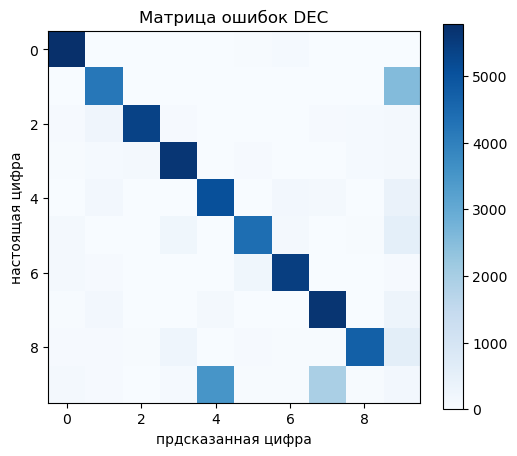

In [23]:
y_dec = soft_assign(ae.encoder(X)).argmax(1).cpu().numpy()
mapping, acc = cluster_accuracy(y, y_dec)
print('DEC: ACC = %.3f'  % (acc))
print('k-means по пикселям:   ACC = %.3f' % cluster_accuracy(y, y_raw)[1])
print('автоэнкодер + k-means: ACC = %.3f' % cluster_accuracy(y, km.labels_)[1])

y_mapped = np.array([mapping[p_] for p_ in y_dec])
cm = confusion_matrix(y, y_mapped)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('прдсказанная цифра')
plt.ylabel('настоящая цифра')
plt.title('Матрица ошибок DEC')
plt.show()